Module importing

In [1]:
import sys
import torch
import random
import numpy as np
import torch.nn as nn
import torch.optim as optim
import scipy.signal as signal
import matplotlib.pyplot as plt
from torch.utils.data import Dataset,DataLoader,TensorDataset,random_split,SubsetRandomSampler, ConcatDataset

sys.path.append('D:/ppg_project/code/model_build/my_tool/model')
from unet_lstm import unet_lstm
sys.path.append(r'D:/ppg_project/code/model_build/my_tool/tool')
from model_builder import k_fold_training
from performance import performance
sys.path.append(r'D:/ppg_project/code/model_build/my_tool/tool/data_load')
from ppg_labeled_load import PPGDataset

Data prepairing

<>:2: SyntaxWarning: invalid escape sequence '\p'
<>:2: SyntaxWarning: invalid escape sequence '\p'
C:\Users\Admin\AppData\Local\Temp\ipykernel_8556\2803335453.py:2: SyntaxWarning: invalid escape sequence '\p'
  dataset = PPGDataset('D:\ppg_project\Data\data_train',label_list = {"Case":["PAC","PVC","PAC-nhip-doi","PAC-cap-doi","PVC-nhip-doi","PVC-cap-doi"],"Group": True})


254
torch.Size([1, 800])


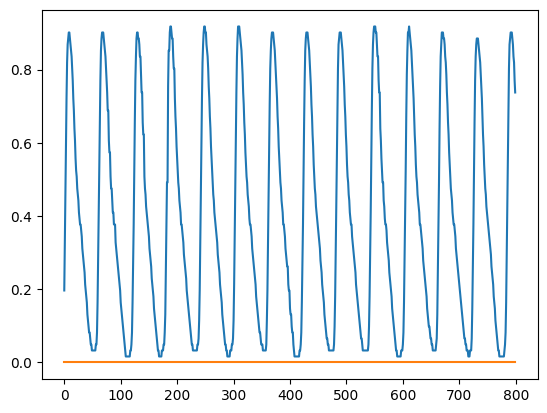

In [2]:
#Import_data
dataset = PPGDataset('D:\ppg_project\Data\data_train',label_list = {"Case":["PAC","PVC","PAC-nhip-doi","PAC-cap-doi","PVC-nhip-doi","PVC-cap-doi"],"Group": True})
print(dataset.count)

print(dataset[111][0].shape)
for i in [22]:
    plt.plot(dataset[i][0].numpy().flatten())
    plt.plot(dataset[i][1].numpy().flatten())

# plt.plot(dataset[0][1].numpy())
    plt.show()

Training

In [6]:
if torch.cuda.is_available():
    device = torch.device('cuda')
else:
    device = torch.device('cpu')

para = {    "Serie length":         800,
            "Input size":           50,
            "Hidden size":          20, # changed hidden size to match with the struct
            "Number layers":        5,
            "Encoder structure":    [1,64,128,256,512], 
            "Decoder structure":    [512,256,128,64,50],
            "Kernel size":          [3,3,3,3,3,3,3,3,3],
            "Down kernel":          [8,8,8,8],
            "Up kernel":            [4,4,4,4],
            "Stride":               [2,2,2,2],
            "Activate function":    nn.Tanh()
    }

model = unet_lstm(para)
optimizer = optim.Adam(model.parameters(), lr=0.0001)
# builder = k_fold_training(train_data, 1, criterion = nn.L1Loss())
builder = k_fold_training(dataset,1,criterion = nn.L1Loss())
builder.training(model,device,optimizer,num_epochs=1500,batch=64,visualize=1)

True
Iteration: 1/1500. loss_train: 0.44587844610214233. loss_val: 0
Iteration: 2/1500. loss_train: 0.42739880084991455. loss_val: 0
Iteration: 3/1500. loss_train: 0.4139663279056549. loss_val: 0
Iteration: 4/1500. loss_train: 0.40526819229125977. loss_val: 0
Iteration: 5/1500. loss_train: 0.4011133015155792. loss_val: 0
Iteration: 6/1500. loss_train: 0.39783379435539246. loss_val: 0
Iteration: 7/1500. loss_train: 0.39428263902664185. loss_val: 0
Iteration: 8/1500. loss_train: 0.3928161859512329. loss_val: 0
Iteration: 9/1500. loss_train: 0.3930589556694031. loss_val: 0
Iteration: 10/1500. loss_train: 0.3911059498786926. loss_val: 0
Iteration: 11/1500. loss_train: 0.3883931636810303. loss_val: 0
Iteration: 12/1500. loss_train: 0.3869554400444031. loss_val: 0
Iteration: 13/1500. loss_train: 0.38637399673461914. loss_val: 0
Iteration: 14/1500. loss_train: 0.38490572571754456. loss_val: 0
Iteration: 15/1500. loss_train: 0.3847718834877014. loss_val: 0
Iteration: 16/1500. loss_train: 0.385

Performance

<>:2: SyntaxWarning: invalid escape sequence '\p'
<>:2: SyntaxWarning: invalid escape sequence '\p'
C:\Users\Admin\AppData\Local\Temp\ipykernel_8556\2692554754.py:2: SyntaxWarning: invalid escape sequence '\p'
  test_data = PPGDataset('D:\ppg_project\Data\data_test',label_list = "AR")


Max loss:  0.9506572
Mean loss:  0.29177883
Min loss:  0.047000695
Number of test:  84


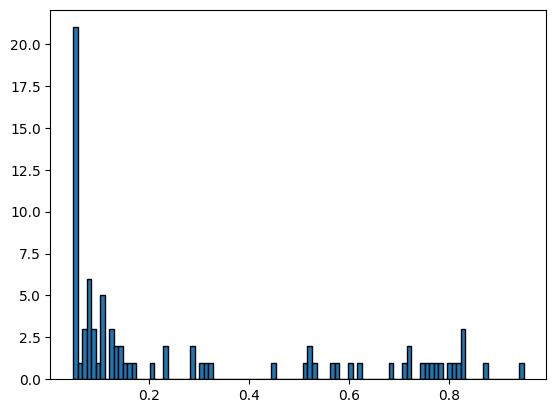

0.20064919


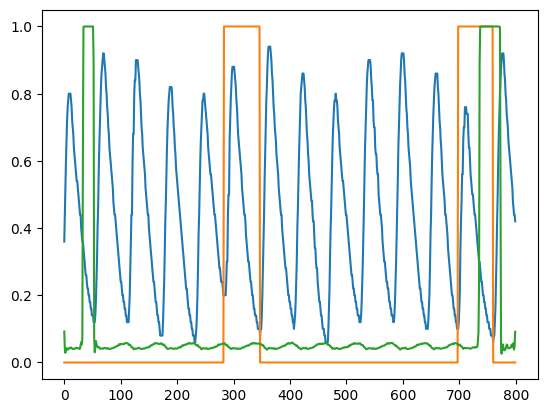

0.77879727


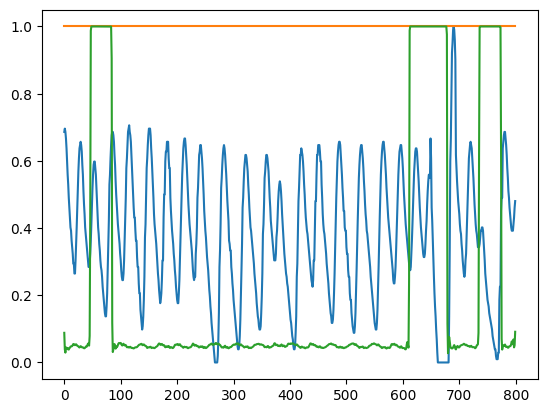

0.6251166


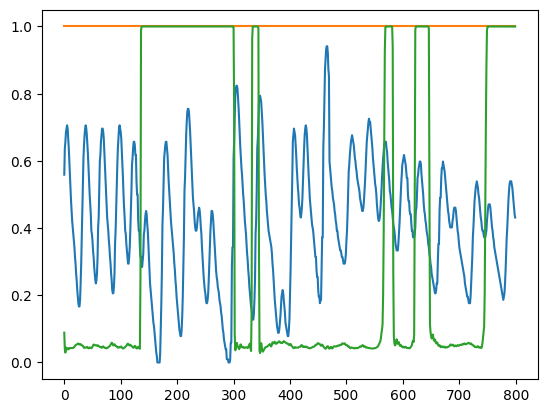

0.10141105


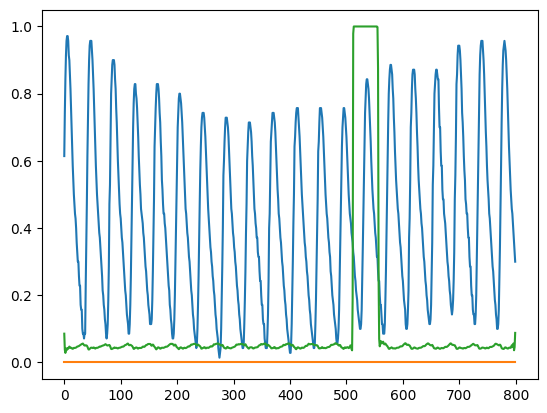

0.047277365


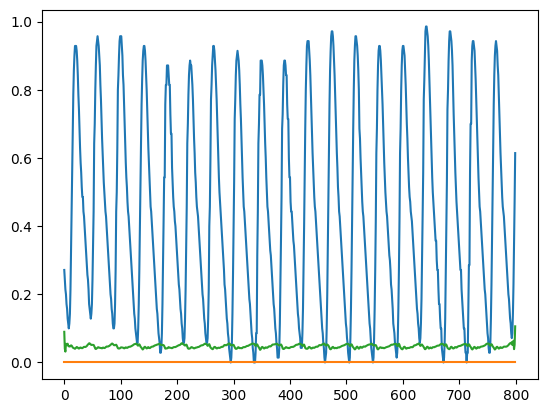

0.047489356


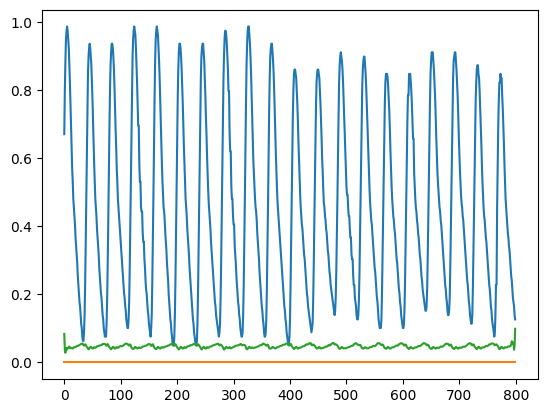

0.047756813


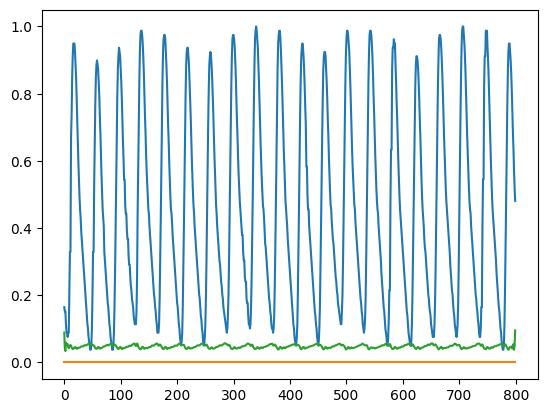

0.06000458


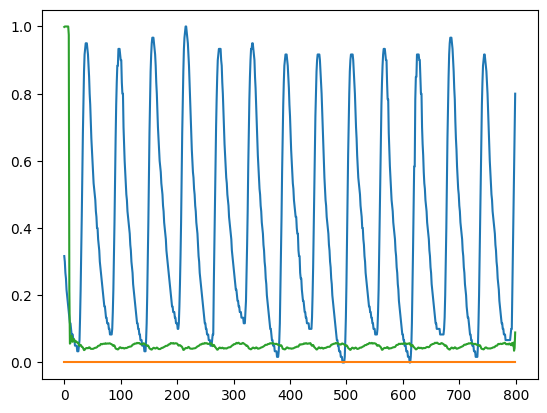

0.04902854


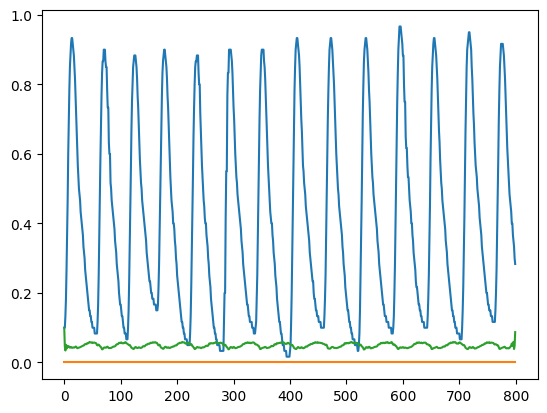

0.047613237


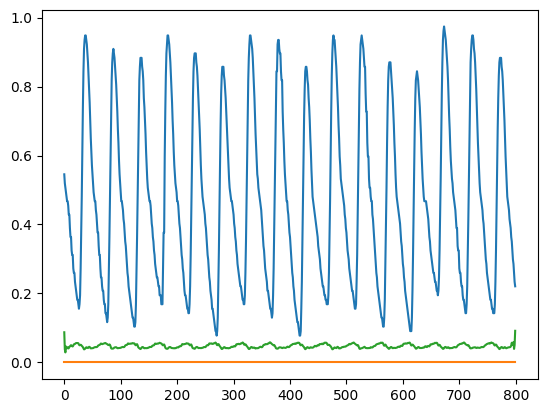

0.10808417


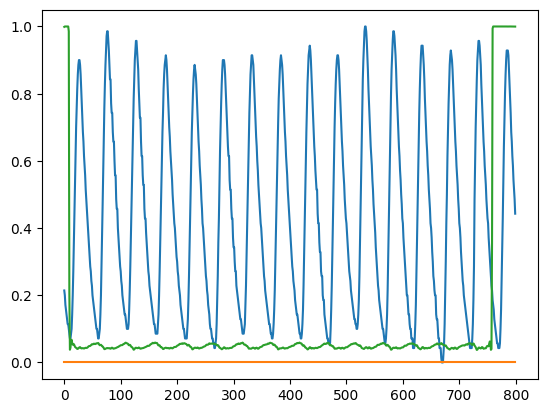

0.04790952


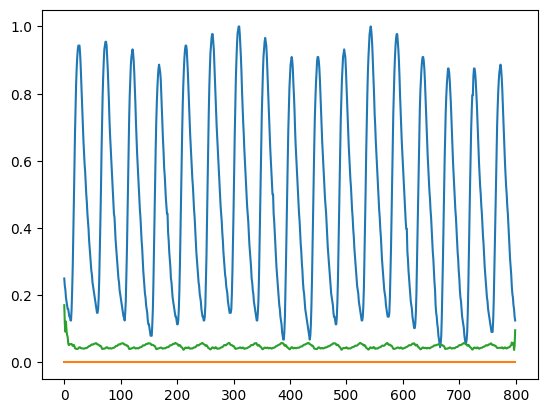

0.17098625


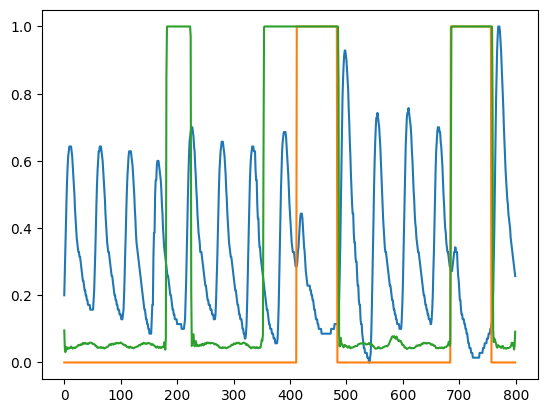

0.122160874


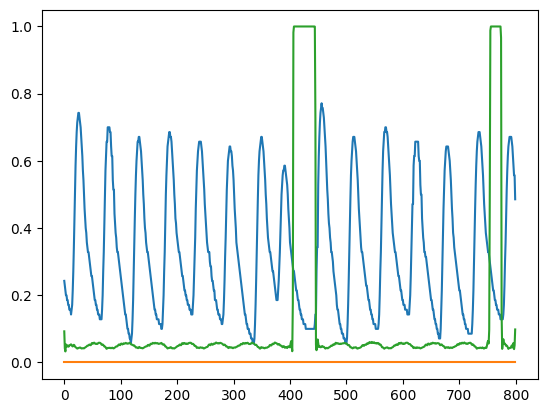

0.13261676


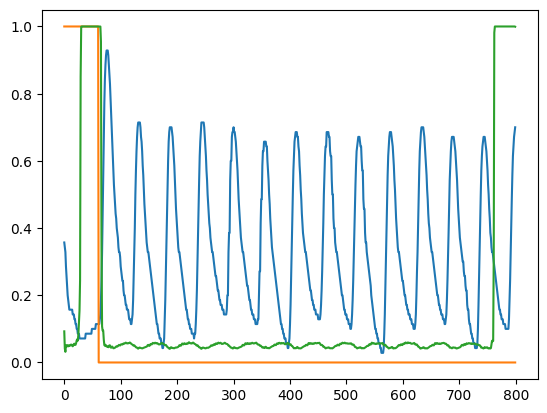

0.07761851


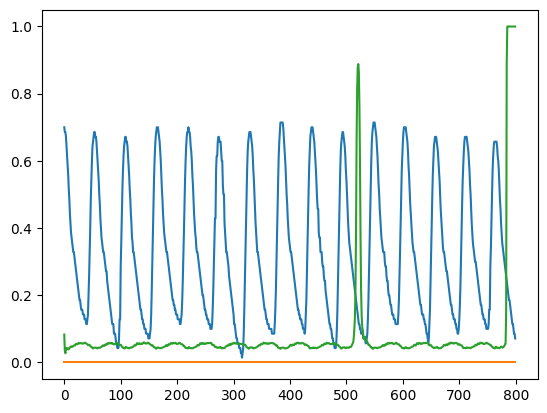

0.8291021


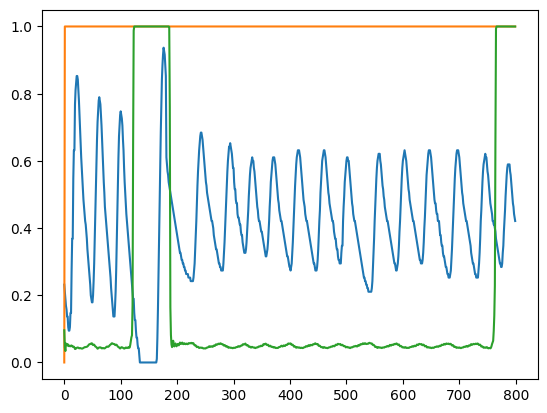

0.76442456


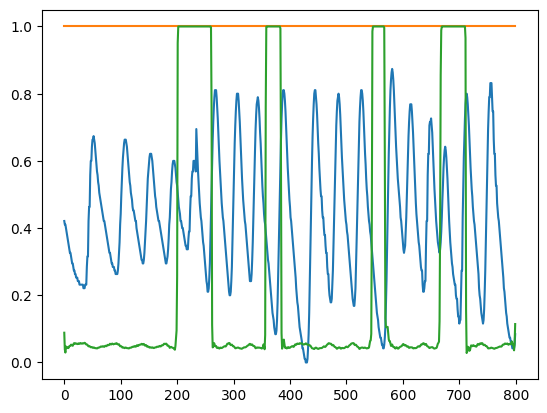

0.718755


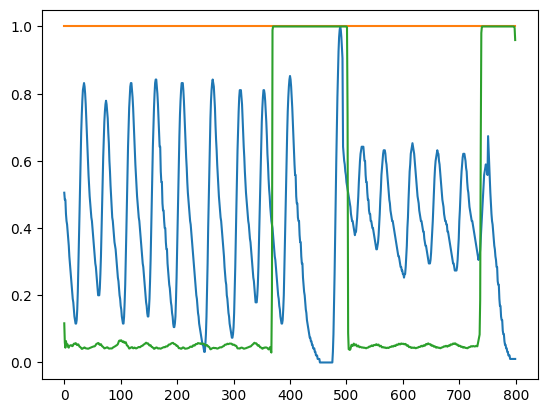

0.7102746


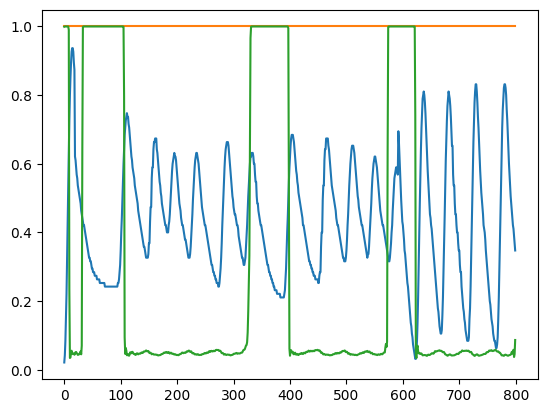

0.7804875


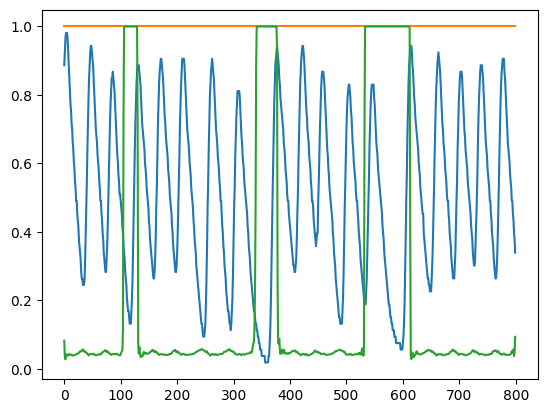

0.121513516


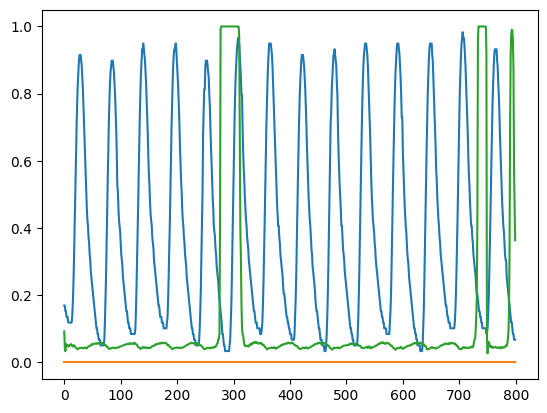

0.088367574


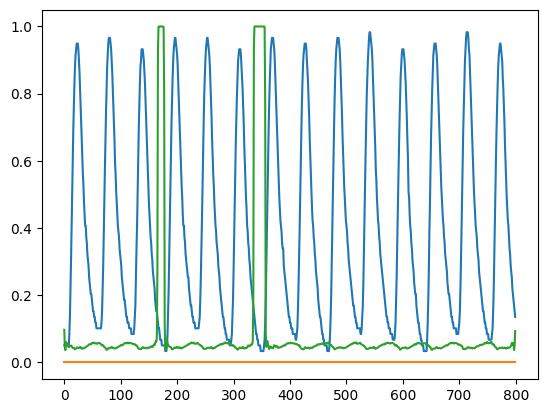

0.047550343


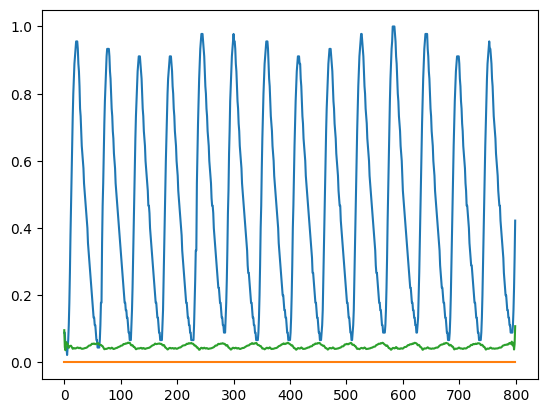

0.10952446


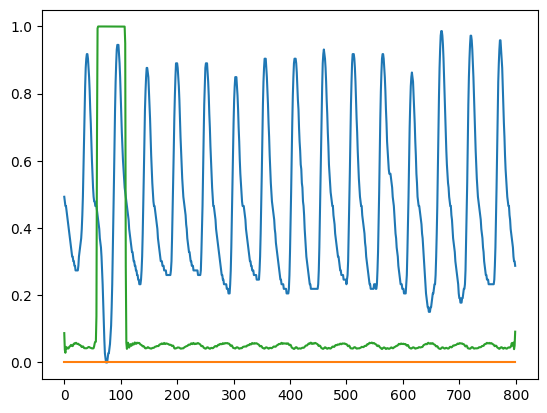

0.049690474


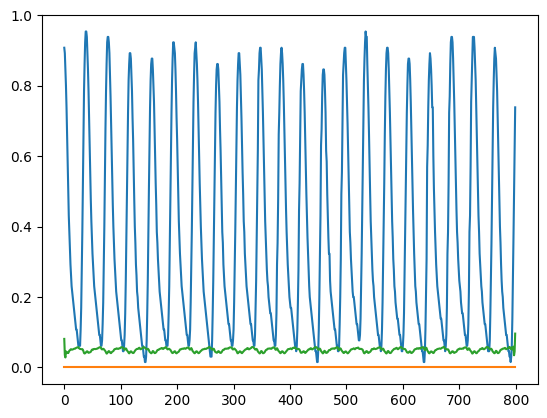

0.5666156


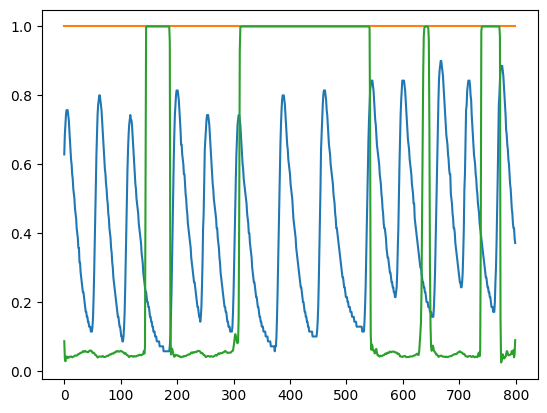

0.047624186


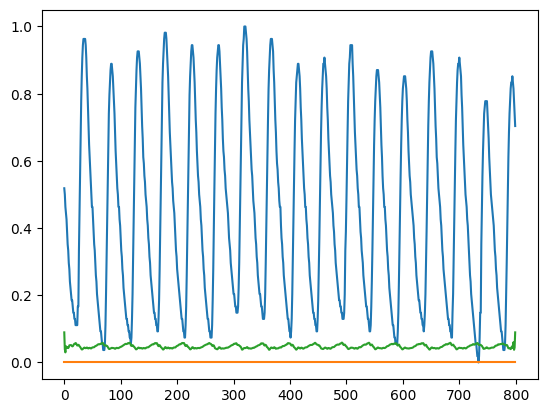

0.047557786


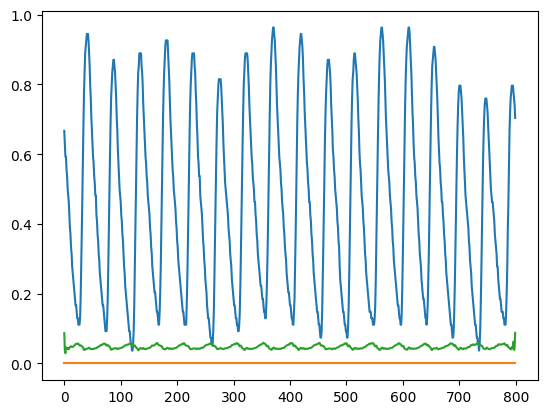

0.5766601


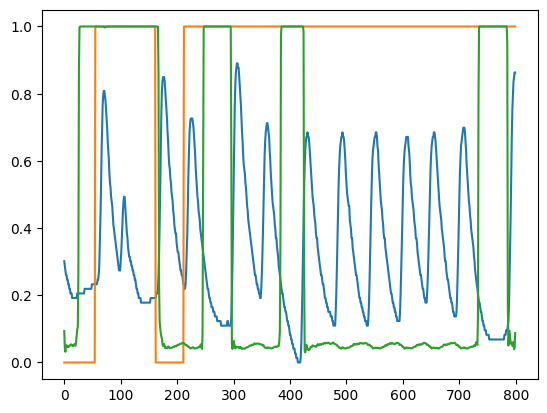

0.048164885


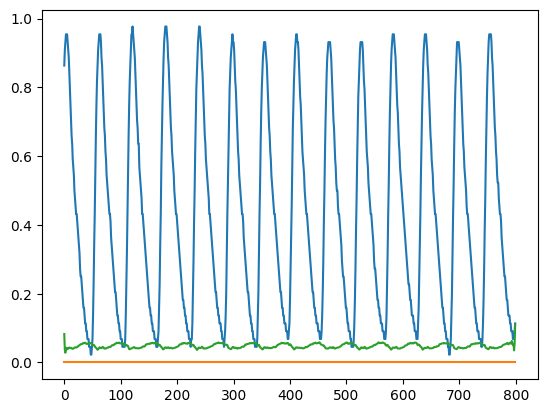

0.07754951


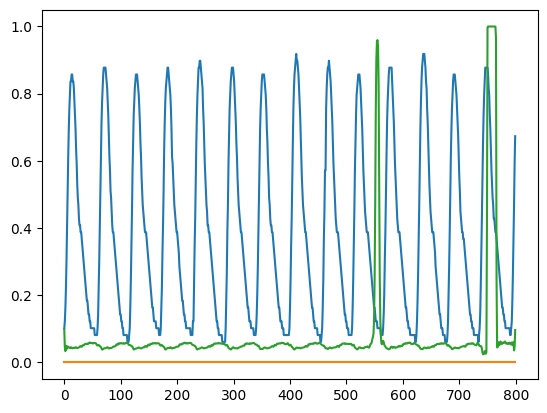

0.047000695


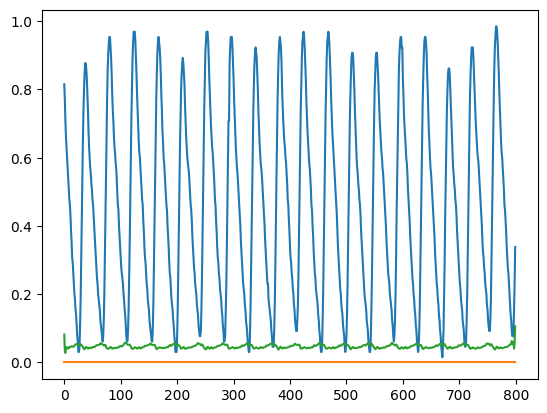

0.048239425


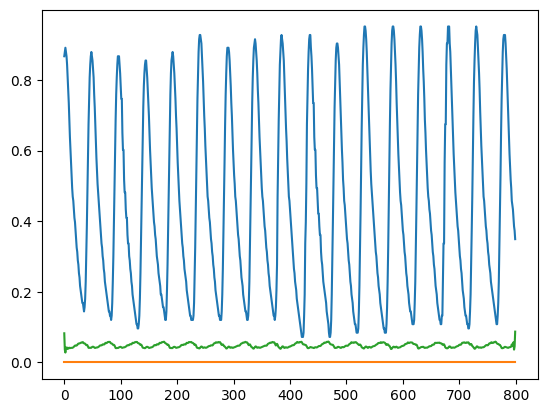

0.07680392


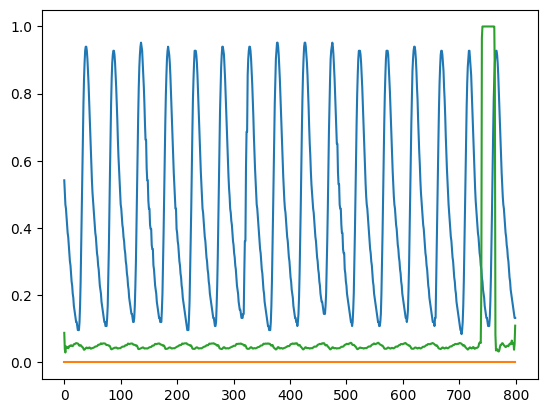

0.04740402


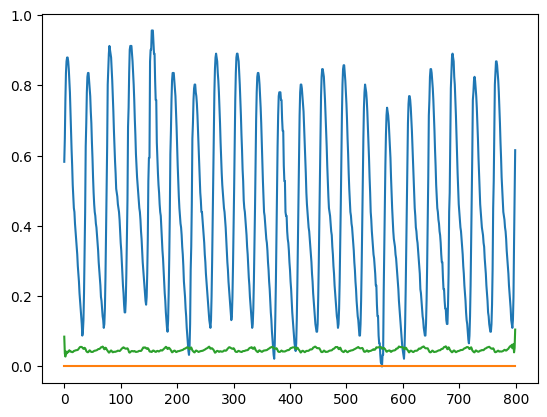

0.07613123


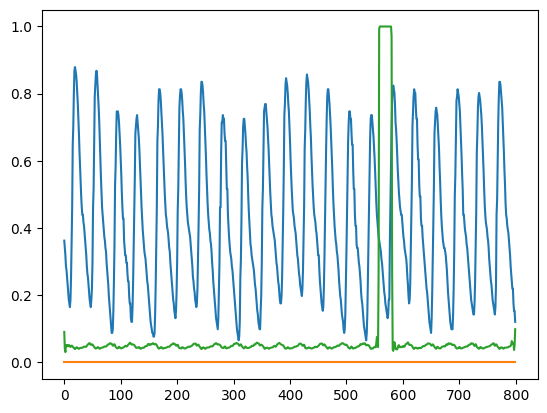

0.047902063


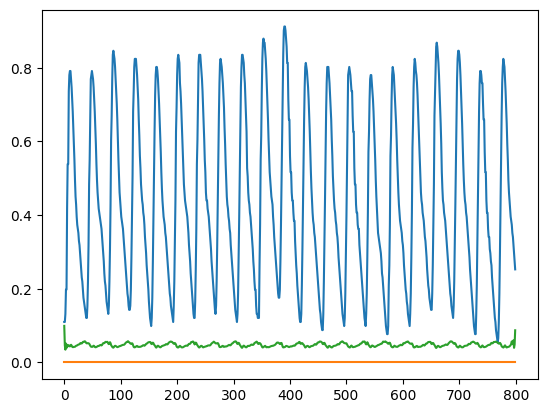

0.14148135


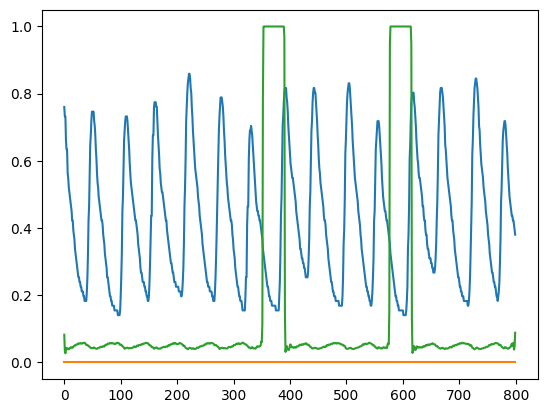

0.52145875


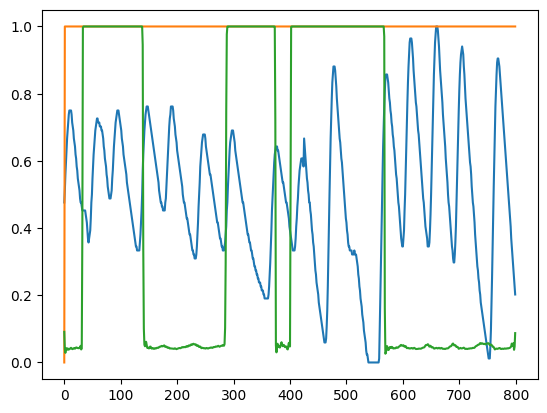

0.06553723


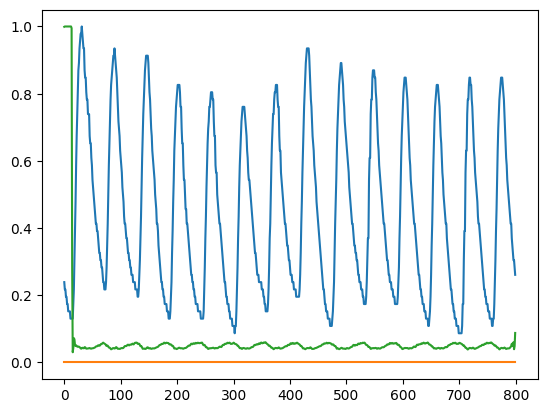

0.6799221


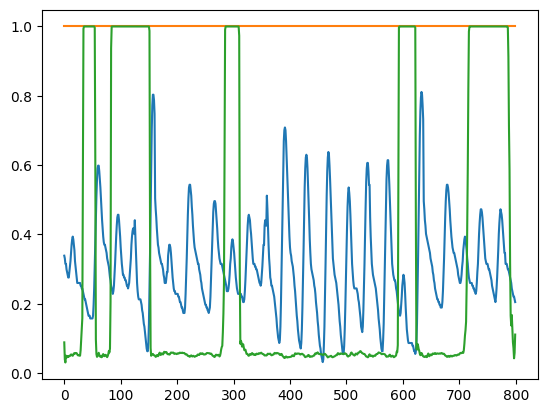

0.7975717


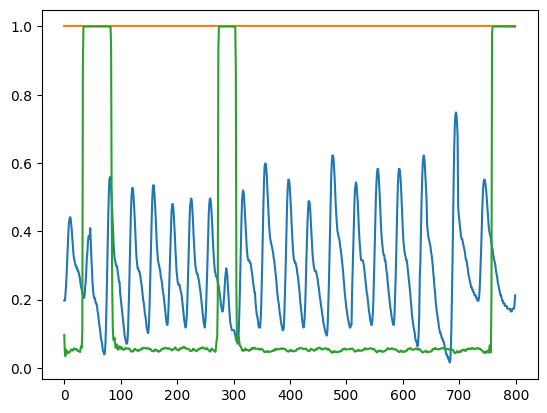

0.050622623


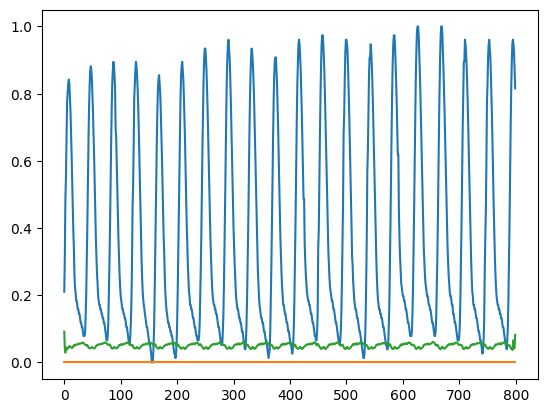

0.103734165


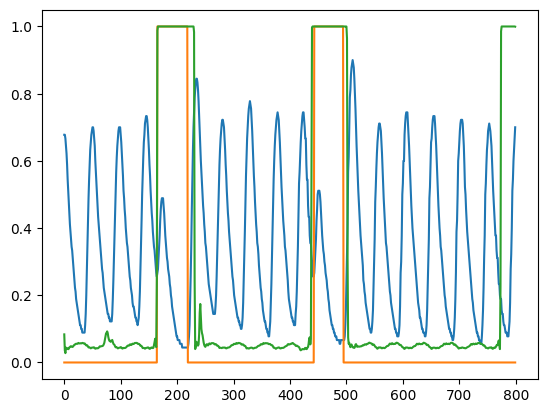

0.14106081


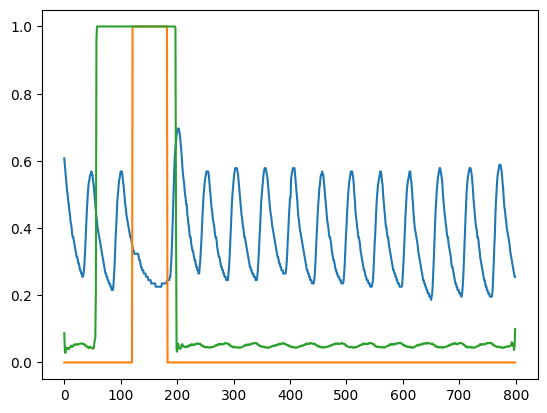

0.32603905


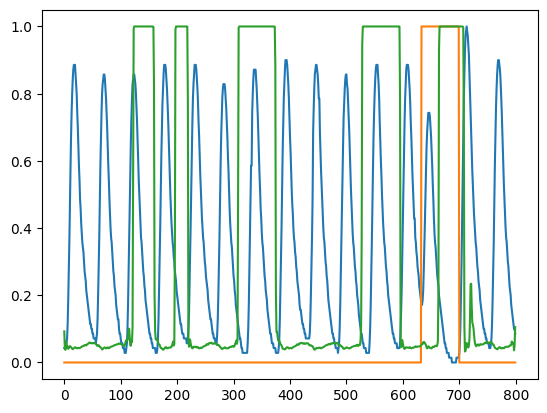

0.5182174


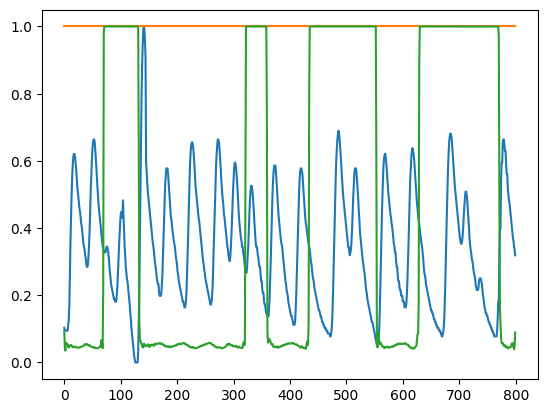

0.7194929


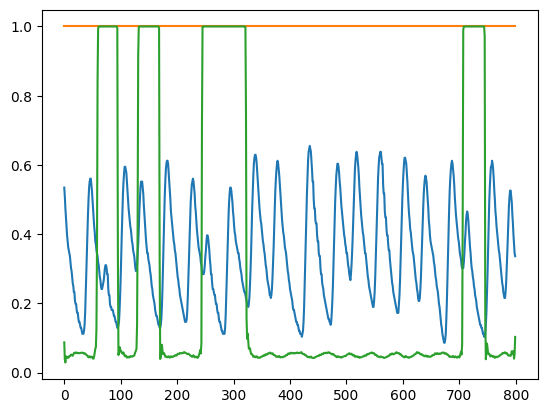

0.08627753


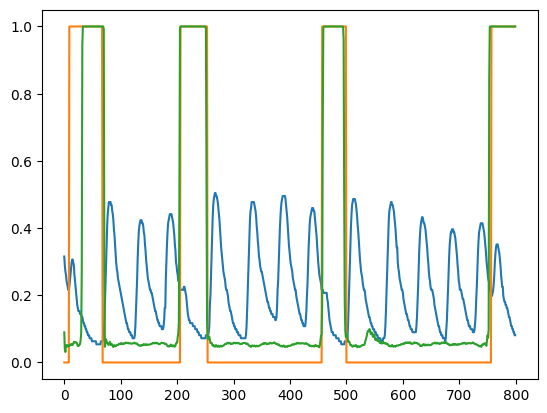

0.15003854


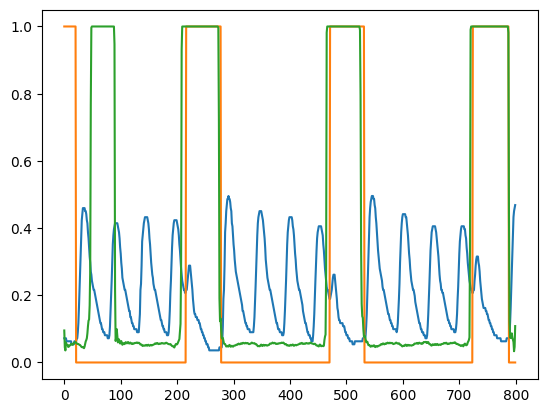

0.12322567


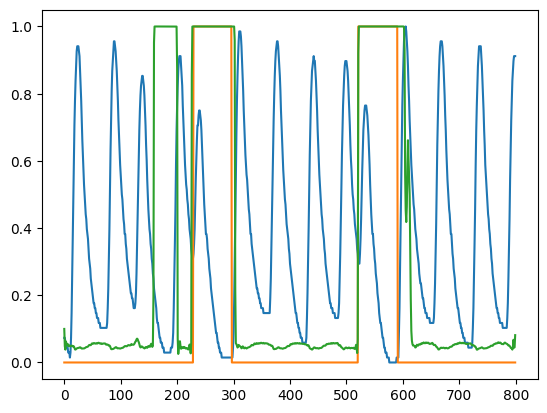

0.10721191


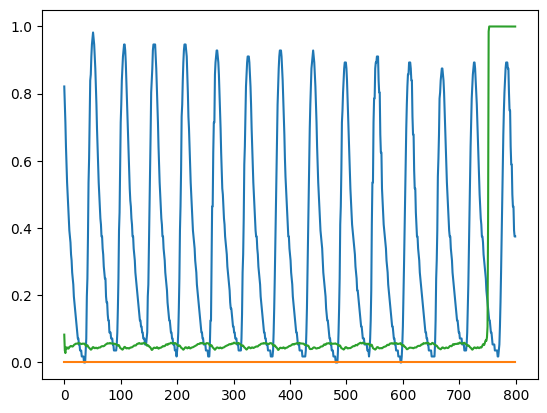

0.047479805


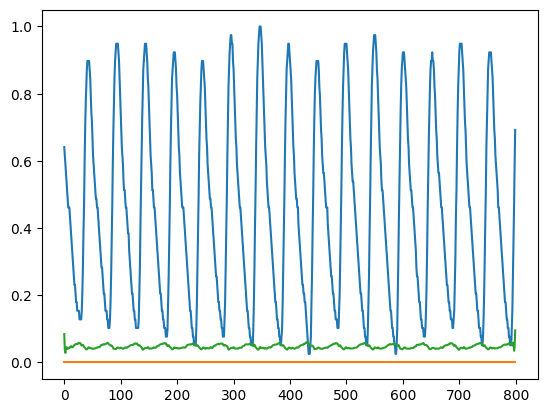

0.04800933


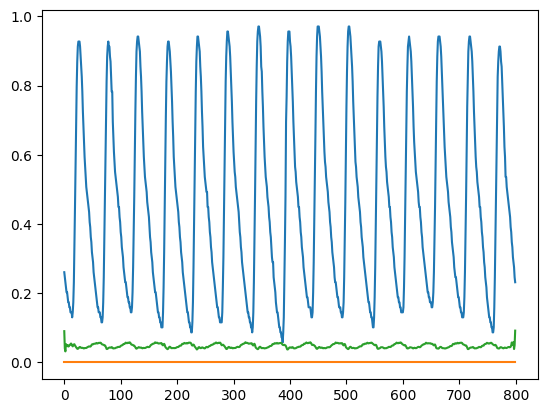

0.53495324


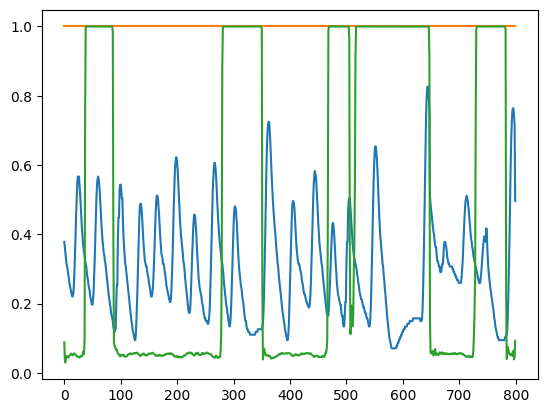

0.45355788


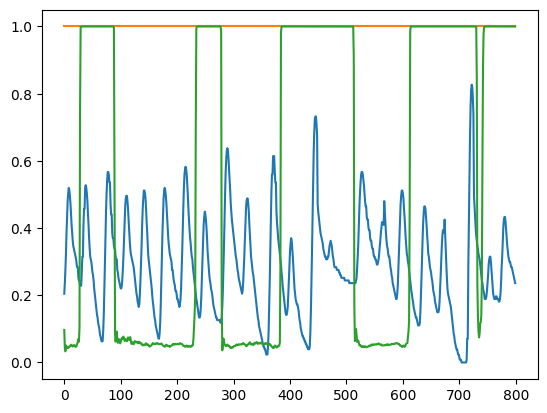

0.07907193


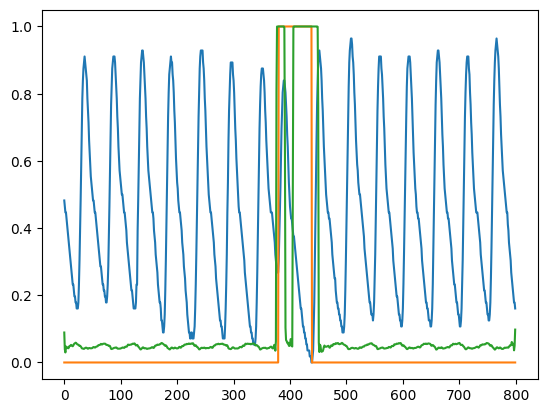

0.81920666


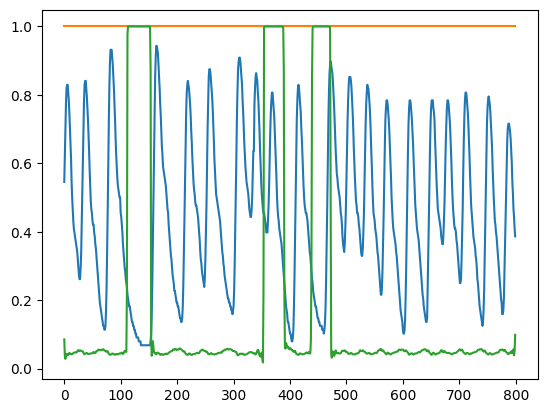

0.5116843


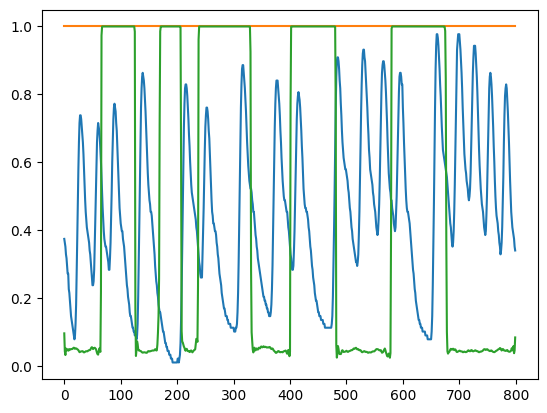

0.8280276


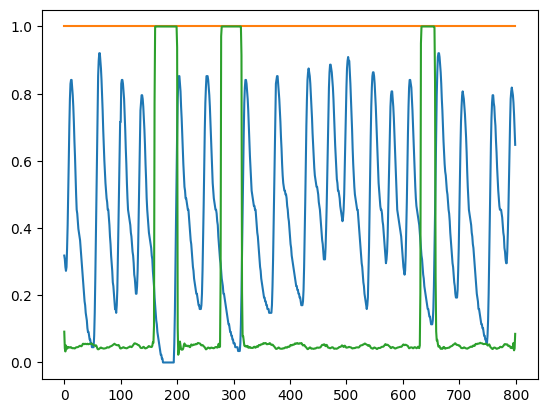

0.2322956


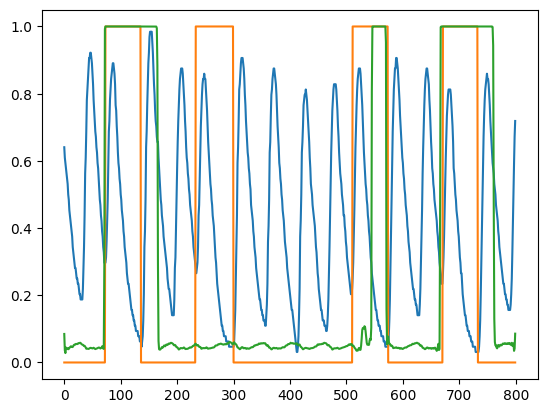

0.3136168


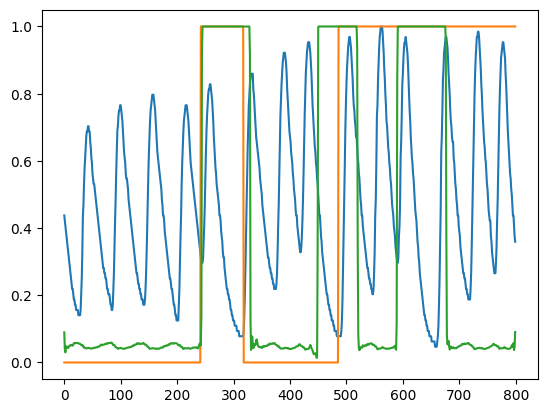

0.06571508


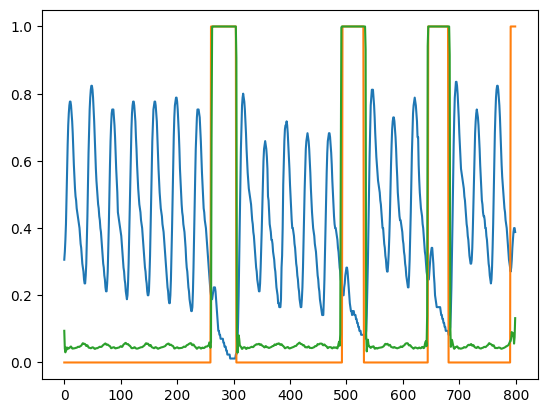

0.2836955


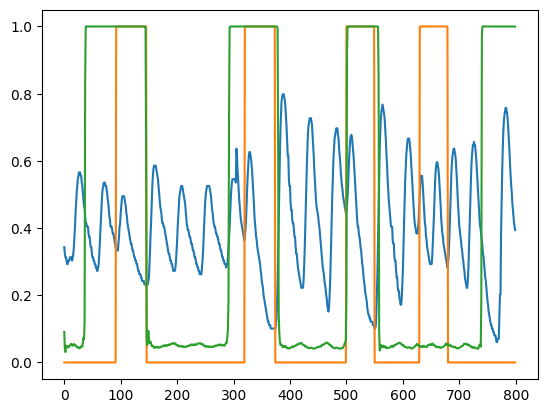

0.048241384


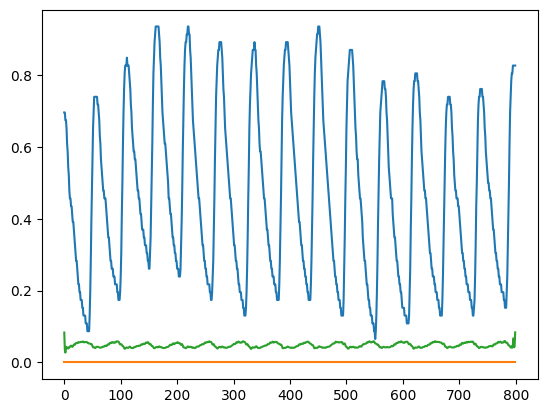

0.60312223


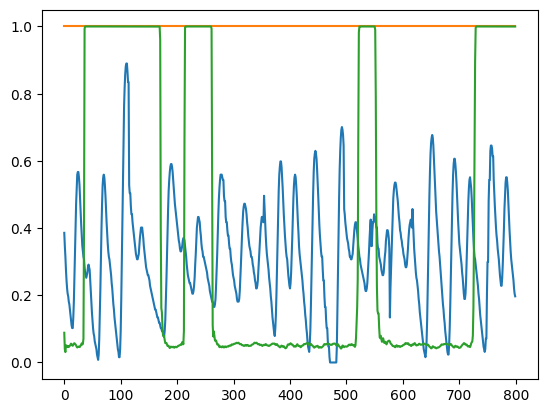

0.08948568


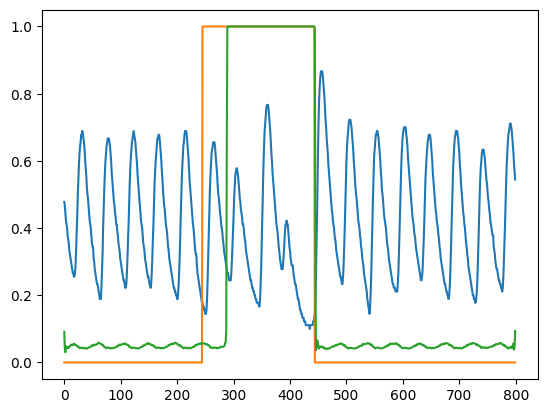

0.23472005


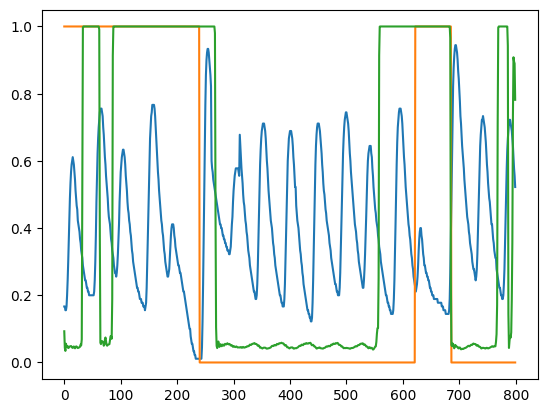

0.077748396


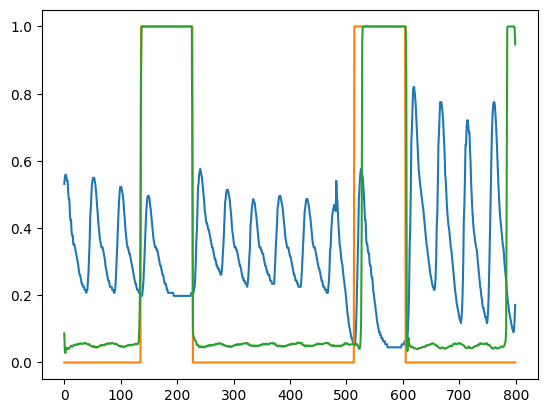

0.15897062


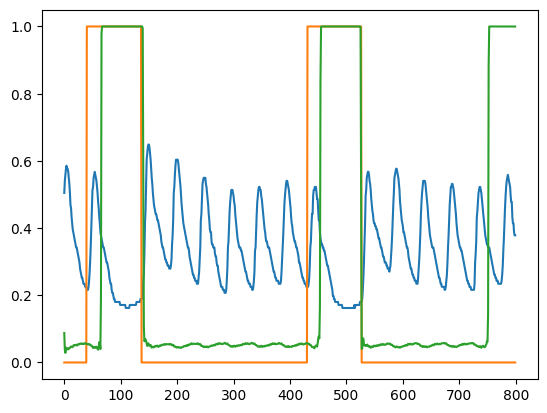

0.1297376


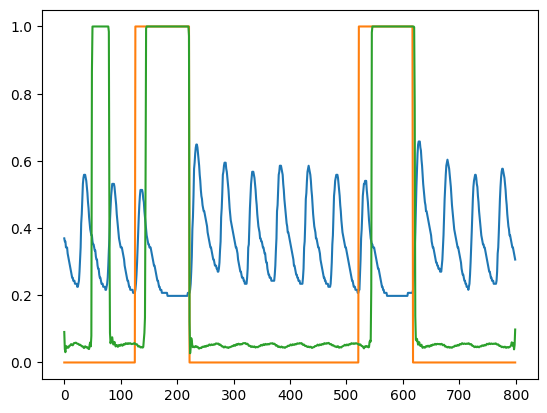

0.07113746


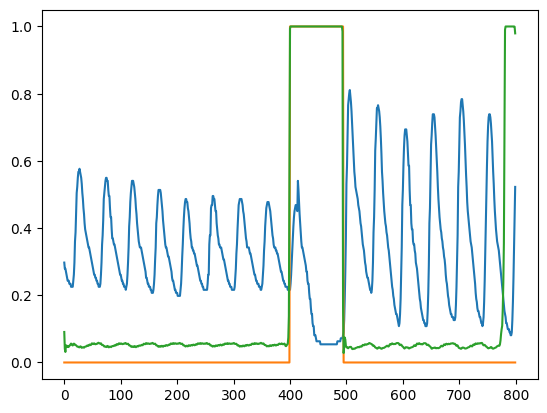

0.048818808


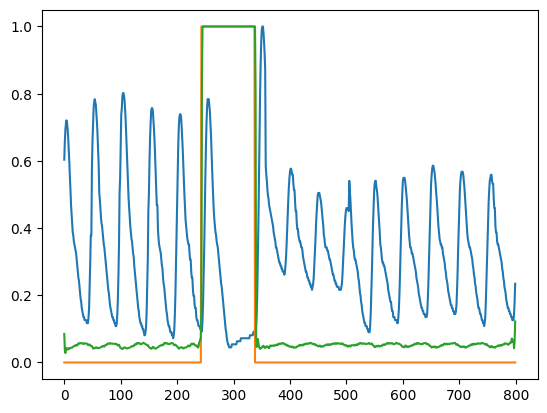

0.8106624


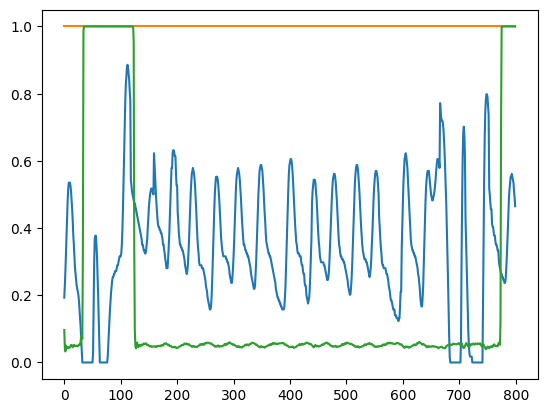

0.75703216


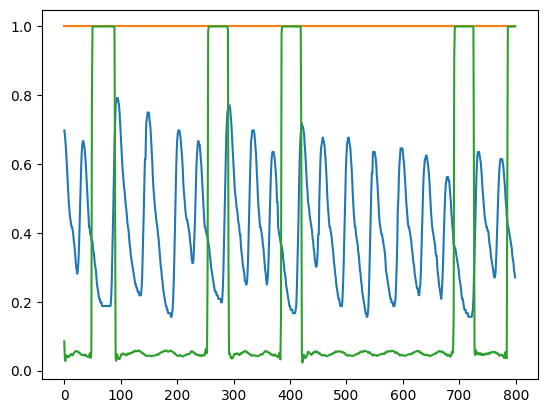

0.9506572


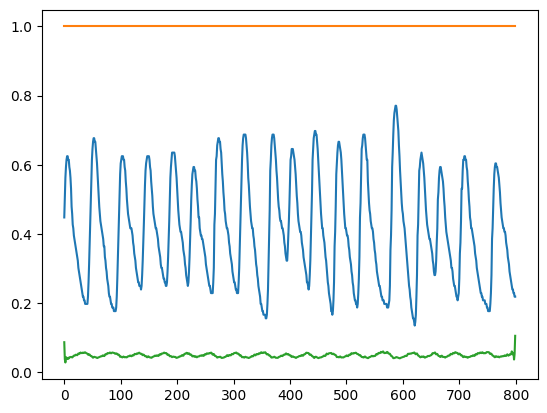

0.8781669


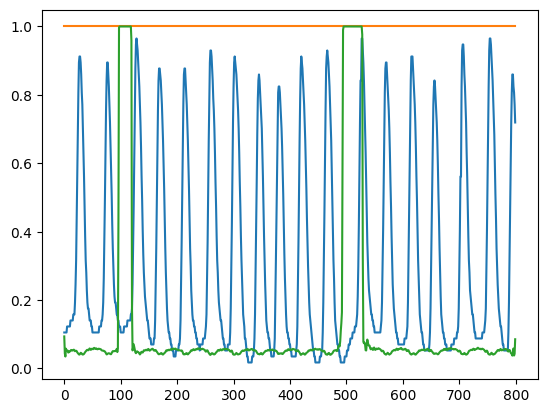

0.28569025


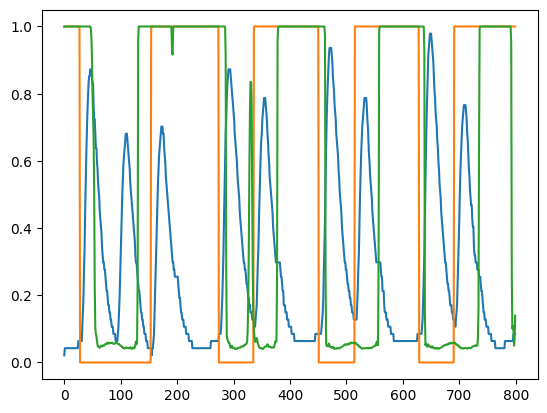

0.30673307


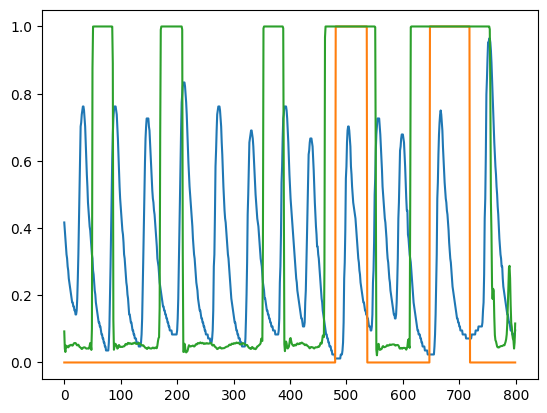

0.7433653


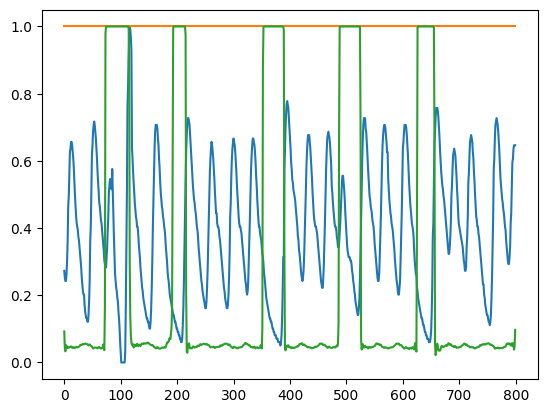

0.8248091


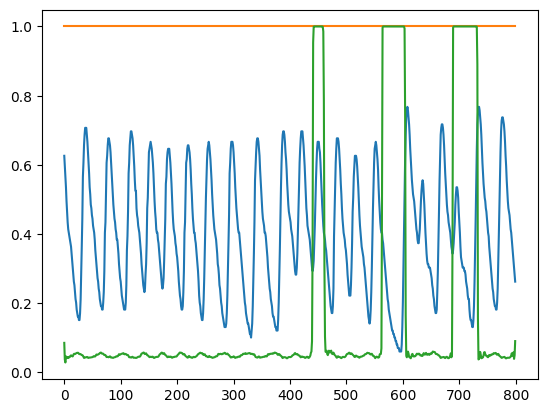

0.09613016


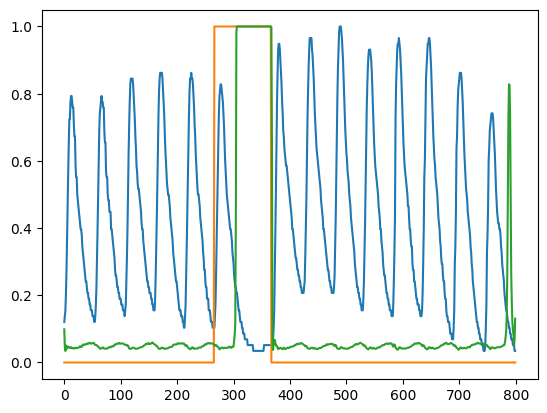

0.05312419


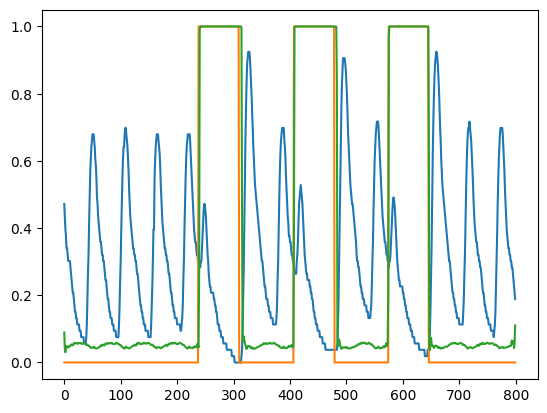

In [7]:
shower = performance()
test_data = PPGDataset('D:\ppg_project\Data\data_test',label_list = "AR")
shower.test(model,device,test_data,per_fnc = "series")
criterion = nn.L1Loss()
for i in range(len(test_data)):
    output = torch.stack([test_data[i][1]]).to(device)
    input = torch.stack([test_data[i][0]]).to(device)
    y_hat = model.forward(input)
    loss = criterion(y_hat,output)
    # if loss.cpu().detach().numpy()<0.3:
    print(loss.cpu().detach().numpy())
    plt.plot(input.cpu().detach().numpy().flatten()[0:1000])
    plt.plot(output.cpu().detach().numpy().flatten()[0:1000])
    plt.plot(y_hat.cpu().detach().numpy().flatten()[0:1000])
    plt.show()